# In-class Assignment 6.2

**Week 6 Wednesday**

#### &#x2705; Write you and your group members' names here

Today, we continue using the modeling cycle.

- **(1)** Pose a question of a real-world physics phenomena.
- **(2a)** Make assumptions about the phenomenon to simplify it into a form that balances two priorities: addressing the core of the question and creating a computational model of the phenomenon.
- **(2b)** Review the resources you have that might be useful for creating a model to answer the question, including: computing/programming tools, physics concepts, numerical methods, existing models.
- **(3a)** Make a plan for creating or refining a computational model, and design tests to validate its effectiveness at answering the question.
- **(3b)** Create or refine a new computational model using your resources and the shared expertise of your group, stepping back to critique and update your plan as needed.
- **(4)** Test the effectiveness of your model using your planned validation process.

---

## Part 1: Verifying a working model

An example of a question and a model for answering it could be:

**How do the frequencies of the plucked guitar note compare to the plucked banjo note?**

And the computational model could involve code somewhat like this:

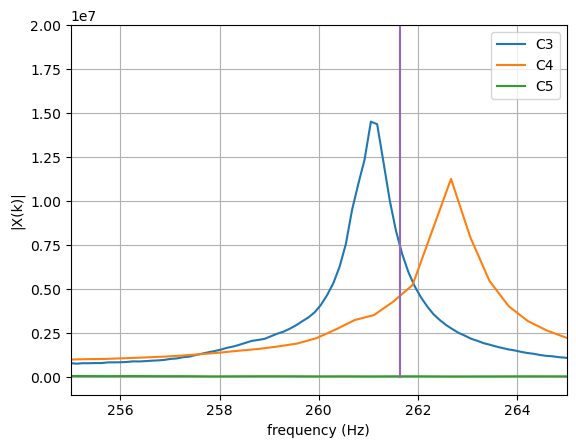

In [47]:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt

#Reads in the data from the wave files
rate_c3, amp_c3 = wav.read("/home/fowlecal/oneGroup/C3.wav")
rate_c4, amp_c4 = wav.read("/home/fowlecal/oneGroup/C4.wav")
rate_c5, amp_c5 = wav.read("/home/fowlecal/oneGroup/C5.wav")

#Gets the length of the audio files
T_c3 = len(amp_c3) / rate_c3
T_c4 = len(amp_c4) / rate_c4
T_c5 = len(amp_c5) / rate_c5

#Fourier Transform to K space
Xk_c3 = np.fft.fft(amp_c3)
Xk_c4 = np.fft.fft(amp_c4)
Xk_c5 = np.fft.fft(amp_c5)

#Get the frequency range
freq_c3 = np.arange(len(Xk_c3)) / T_c3
freq_c4 = np.arange(len(Xk_c4)) / T_c4
freq_c5 = np.arange(len(Xk_c5)) / T_c5

c3x = [130.81, 130.81]
c3y = [0, 2e8]
c4x = [261.63, 261.63]
c4y = [0, 2e7]
c5x = [523.25, 523.25]
c5y = [0, 2e7]
#Plot the Wave in k space vs frequency
plt.plot(freq_c3, np.abs(Xk_c3), label="C3")
plt.plot(freq_c4, np.abs(Xk_c4), label="C4")
plt.plot(freq_c5, np.abs(Xk_c5), label="C5")
plt.plot(c3x, c3y)
plt.plot(c4x, c4y)
plt.plot(c5x, c5y)
#Labeling the Axis
plt.xlabel("frequency (Hz)")
plt.ylabel("|X(k)|")
#Limiting the plot to these ranges
plt.xlim(255, 265)
plt.ylim(-1e6, 2e7)
#Showing the graph
plt.legend()
plt.grid()
plt.show()

To verify this model answers the question, you can notice differences between intensities of frequency peaks, combinations of different frequency peaks across each instrument, and other differences between the two frequency distributions.

You can even use an inverse FFT to bring a frequency distribution back into its amplitudes, and play the audio out loud:

In [48]:
from IPython.display import Audio

#Inverse Fourier Transform
ifft_amp_c3 = np.fft.ifft(Xk_c4)

#Plays the audio
Audio(ifft_amp_c4, rate=rate_c4)

NameError: name 'ifft_amp_c4' is not defined

&#x2705; Your group might have different code than above. Bring your computational model from ICA 6.1 into this notebook. 

&#x2705; You are also welcome to use the above code for today's assignment if your group agrees on doing this and takes the time to go through and **explain what each part of the code is doing by filling in the empty comments.**

&#x2705; List the comparisons and differences you can draw between the two frequency distributions.

The highest amplitude is at the lowest frequency.

The lower the note the faster the fall off of amplitude for the harmonics.
The spacing between harmonics increases as the note increases in pitch

---

## Part 2: Using a working model

At the end of the modeling cycle we have Step 4: Test the effectiveness of your model using your planned validation process.

This is what you did above in Part 1.

From here, we can return to Step 1: Pose a question of a real-world physics phenomena.

However, we do not have to immediately try to push the boundaries of our model and force ourselves to refine our model further (that would entail continuing on to Step 2 and 3). Instead, we can use our model to see what else it can enable us to investigate. There are many questions we could answer without needing to reinitiate the modeling cycle.

You now have the tools you need to translate back from a frequency distribution to an audio sample. You can even test out some of the comparisons you made at the end of Part 1. For example, *does the banjo twang really come from those high-frequency peaks?*

&#x2705; Today, use your model of the frequency distributions to investigate new questions. You can edit the existing frequencies however you like, and test your changes through plotting, listening to the resulting audio, or any other method your group comes up with.